# 01. Data and Model

**Front half of the project. This notebook is finished.**

It builds the problem instance, defines the model, and solves a baseline case. The actual code lives in `src/`, so this notebook is a readable walkthrough rather than a wall of code. If you are picking this project up, read this top to bottom, then open `02_analysis.ipynb`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import data_prep
from model import solve_model, summarize
from plotting import plot_instance, plot_solution

## Step 1. Study area

A box over the near north and west side of Chicago. Keeping the area bounded keeps the candidate list small, so the exact solver finishes in seconds instead of minutes.

In [2]:
print(f'longitude: {data_prep.WEST} to {data_prep.EAST}')
print(f'latitude : {data_prep.SOUTH} to {data_prep.NORTH}')
print(f'center   : {data_prep.CENTER} (the Loop)')

longitude: -87.72 to -87.6
latitude : 41.85 to 41.95
center   : (-87.6298, 41.8781) (the Loop)


## Steps 2 to 5. Build the instance

- **Candidate sites**: 20 real Chicago parking garages and fuel stations. They already have the space and the grid access a charging station needs.
- **Demand points**: an 8 by 7 grid over the study area, each cell center standing for the EV drivers in that cell.
- **Parameters**: cost, demand weight, and capacity are assumed, not measured. The reasoning is documented in `src/data_prep.py` and repeated in the assumptions section below.
- **Distances**: great circle (haversine) in km. A plain Euclidean distance on raw longitude and latitude would be wrong, since a degree of longitude is shorter than a degree of latitude at this latitude.

In [3]:
sites, demands, D = data_prep.build_all(data_dir='../data')

print(f'candidate sites  : {len(sites)}')
print(f'demand points    : {len(demands)}')
print(f'distance matrix  : {D.shape}, {D.min():.2f} to {D.max():.2f} km')
print(f'total demand     : {demands.weight.sum():,}')
print(f'total capacity   : {sites.capacity.sum():,}')
print(f'cost to build all: ${sites.cost.sum():,}')

candidate sites  : 20
demand points    : 56
distance matrix  : (56, 20), 0.16 to 11.76 km
total demand     : 23,248
total capacity   : 63,800
cost to build all: $2,509,000


In [4]:
sites.head()

,site_id,lon,lat,amenity,cost,capacity
0,S00,-87.6270,41.8827,parking,192000,4000
1,S01,-87.6195,41.8853,parking,176000,4000
2,S02,-87.6338,41.8919,parking,166000,4000
3,S03,-87.6410,41.8994,fuel,145000,2200
4,S04,-87.6553,41.9120,parking,117000,4000


In [5]:
demands.head()

,demand_id,lon,lat,weight
0,D00,-87.714000,41.856,293
1,D01,-87.698571,41.856,311
2,D02,-87.683143,41.856,414
3,D03,-87.667714,41.856,468
4,D04,-87.652286,41.856,451


### Assumptions

These are stated as assumptions in the report, not presented as data.

| Parameter | Assumption | Reasoning |
|---|---|---|
| Demand weight | about 900 near the Loop down to about 120 at the edge, 15% noise | density and daytime population are highest downtown |
| Construction cost | about \$210k downtown down to about \$60k at the edge | land prices fall with distance from the center |
| Capacity | 4000 per day for garages, 2200 for fuel stations | garages have room for more charging ports |

The capacity number matters more than it looks. Total capacity is about 2.8 times total demand, so roughly a third of the sites is enough to serve the area. That is deliberate: it leaves the model a real choice about which sites to build. An earlier version used capacities about 8 times smaller, which forced nearly every site to be built and made the sensitivity curves flat and uninteresting.

### The instance before optimizing

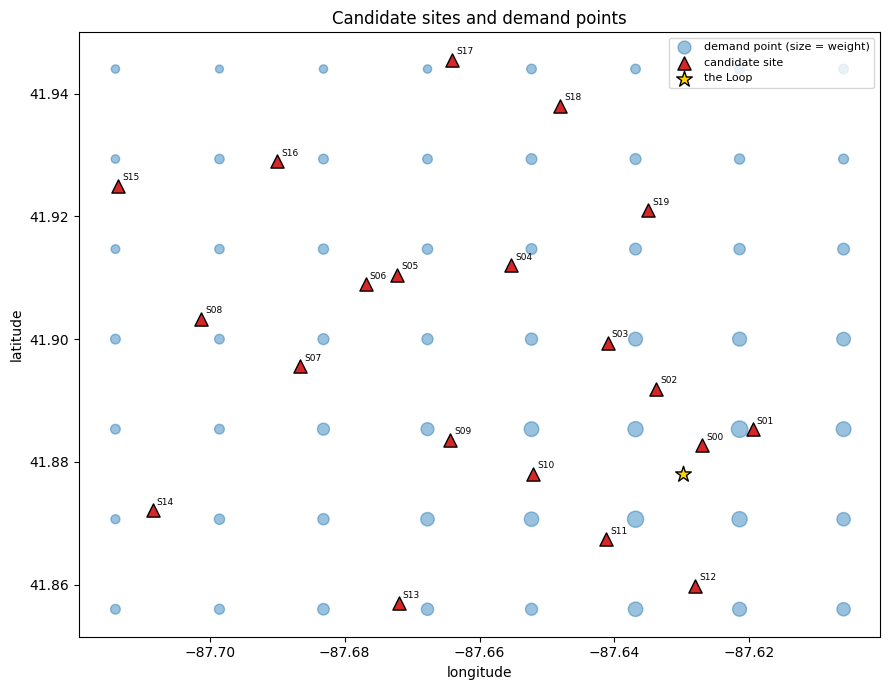

In [6]:
plot_instance(sites, demands)
plt.tight_layout(); plt.show()

## Step 6. Save

`build_all()` already wrote `data/sites.csv`, `data/demands.csv`, and `data/distance.npy`. Later notebooks can call `data_prep.load_all()` instead of rebuilding.

## Step 7. The model

The model is in `src/model.py` as `solve_model()`. It is a function, not a script, because the whole back half is built by calling it repeatedly with different budgets, radii, and capacities.

**Decision variables**
- `y_j` in {0, 1}: build a station at candidate site j or not
- `x_ij` in [0, 1]: the fraction of demand at point i served by station j

**Objective**, in `min_cost` mode: minimize construction cost plus lambda times weighted travel cost. In `max_coverage` mode: maximize demand served under a fixed budget.

**Constraints**
- demand satisfaction: fractions at each demand point sum to 1 (or at most 1 in coverage mode)
- linking: `x_ij <= y_j`, demand can only go to a site that was built
- service radius: `x_ij = 0` whenever the distance exceeds the radius
- capacity: demand assigned to a site cannot exceed its capacity
- budget: total construction cost stays within budget

In [7]:
help(solve_model)

Help on function solve_model in module model:

solve_model(sites, demands, D, budget, radius, lam=1.0, mode='min_cost', capacity_scale=1.0, msg=False)
    Solve the capacitated facility location model.

    Parameters
    ----------
    sites : DataFrame
        Needs columns site_id, cost, capacity.
    demands : DataFrame
        Needs columns demand_id, weight.
    D : ndarray
        Distance matrix in km. D[i, j] is demand point i to site j.
    budget : float
        Total construction budget in dollars.
    radius : float
        Maximum acceptable driving distance in km. Demand cannot be assigned
        to a site further away than this.
    lam : float
        Converts one demand-km of travel into dollars. Only used in min_cost
        mode, where it sets the balance between building and driving.
    mode : {"min_cost", "max_coverage"}
        min_cost     : every demand point must be served, minimize
                       construction cost plus weighted travel cost.
        

## Step 8. Baseline solve and sanity check

In [8]:
BUDGET, RADIUS = 1_200_000, 5.0
res = solve_model(sites, demands, D, budget=BUDGET, radius=RADIUS, lam=1.0)
summarize(res, sites, label=f'baseline, budget ${BUDGET:,}, radius {RADIUS} km')
print()
display(sites.iloc[res['built']][['site_id', 'amenity', 'cost', 'capacity']])

[baseline, budget $1,200,000, radius 5.0 km] status: Optimal
  stations built   : 6 of 20
  construction cost: $643,000
  demand covered   : 23,248 (100.0%)
  average drive    : 2.59 km
  objective        : 703,188



,site_id,amenity,cost,capacity
4,S04,parking,117000,4000
8,S08,parking,95000,4000
12,S12,parking,155000,4000
14,S14,parking,95000,4000
16,S16,parking,88000,4000
18,S18,parking,93000,4000


**Sanity check.** The solve is Optimal, it builds 6 of 20 sites, spends well under budget, and serves 100 percent of demand at an average drive of about 2.6 km. All of that is plausible. Building zero sites or all 20 would both mean the parameters are wrong, which is worth checking before any analysis is built on top.

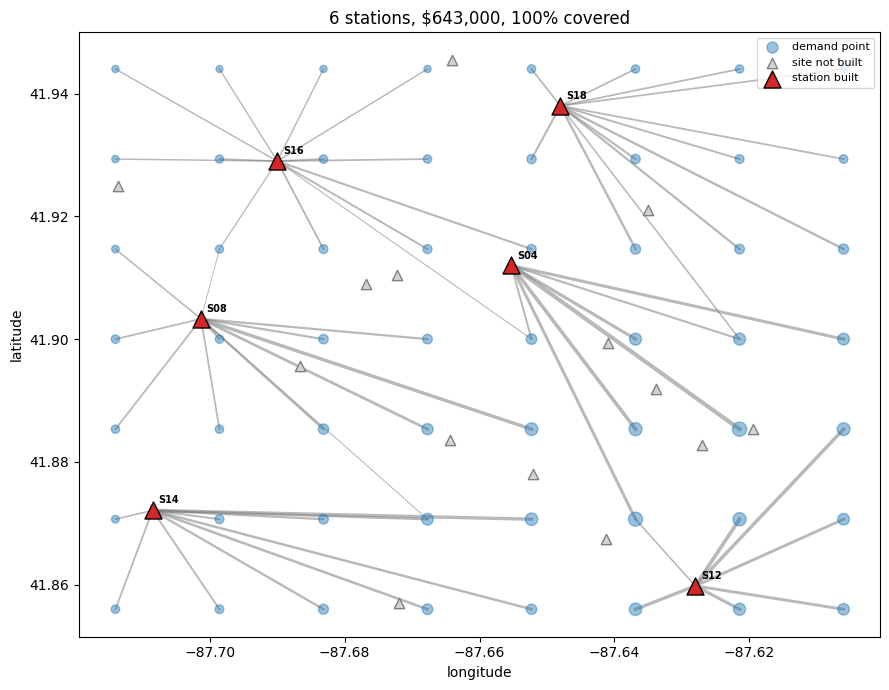

In [9]:
plot_solution(res, sites, demands, annotate=True)
plt.tight_layout(); plt.show()

### Feasibility limits

Useful for choosing sensible sweep ranges in the next notebook.

In [10]:
rows = []
for R in [3, 4, 5, 6, 8]:
    r = solve_model(sites, demands, D, budget=10**9, radius=R)
    rows.append({'radius_km': R, 'status': r['status'],
                 'min_cost_to_serve_all': r['total_cost'],
                 'n_sites': len(r['built']),
                 'avg_drive_km': r['avg_distance']})
pd.DataFrame(rows)

,radius_km,status,min_cost_to_serve_all,n_sites,avg_drive_km
0,3,Infeasible,NaN,0,NaN
1,4,Optimal,714000.0,6,2.091476
2,5,Optimal,643000.0,6,2.588944
3,6,Optimal,633000.0,6,2.770937
4,8,Optimal,595000.0,6,3.417042


At a 3 km radius the problem is **infeasible**: at least one demand point has no candidate site within reach. That sets the lower end of the radius sweep, and it is a finding worth reporting on its own.

---

## Handoff to the back half

Everything from here is built by calling `solve_model()`. You should not need to change the model itself. Open `02_analysis.ipynb`, which already has the scaffolding and the instructions.

One number to start from: a quick budget sweep in `max_coverage` mode gives coverage rising from about 34 percent at \$200k to 100 percent at \$700k, then flat. The knee of that curve is the headline result of the whole project.